# Lending Club EDA -- F7 -- Target, Outcome & Objective-Oriented Analysis

**Status: built.** See the cell map below for what's actually in this notebook.

## What this notebook covers

What loan_status actually contains, how is_bad is defined and why, the resulting class balance, and what optimizing for this specific target does and doesn't capture about real-world loan performance (e.g. partial recovery on charge-offs, the excluded 'still open' loans).

## Where this fits

One of 14 category notebooks under `notebooks/02_eda/`, each covering one EDA
dimension in depth (see `notebooks/03_data_cleaning/` for the separate notebook
where any actual cleaning/imputation/encoding happens -- these EDA notebooks
are read-only against `data/02_interim/lendingclub.duckdb` and never modify
or clean the data themselves). Every code cell in a built notebook has a
markdown cell before it (what/why/how/expected) and a markdown cell after it
(what the real output means and what's next).


## Cell map

| # | What it does |
|---|---|
| 1 | Connect; loan_status breakdown, is_bad definition, class balance |
| 2 | What gets excluded by is_bad's definition -- still-open loans and the boundary between "Default" and "Charged Off" |
| 3 | What optimizing for is_bad does and doesn't capture -- recovery amounts among charged-off loans |

## Cell 1 -- loan_status, is_bad, and class balance

**What / why:** Confirming the target definition on the actual modeling
population (`windowed`) rather than the full matured set: `is_bad = 1` for
Charged Off / Default / the "does not meet credit policy" charged-off
variant, `is_bad = 0` for Fully Paid / the paid-off variant. Everything
downstream (every IV number, every WOE table) is relative to this
definition, so it deserves its own direct look rather than being assumed.

**Expect:** roughly 20% bad rate, consistent with the 20.0% seen on the
full matured population before windowing.

loan_status  is_bad      n
 Fully Paid       0 950468
Charged Off       1 245378
    Default       1     33

overall bad rate: 20.5%


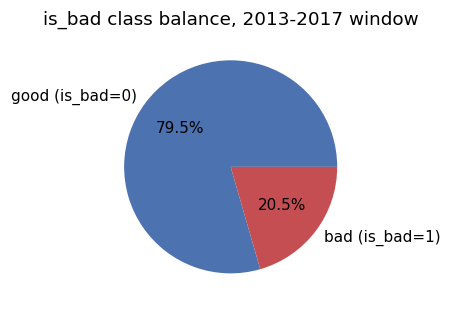

In [1]:
import os, duckdb, pandas as pd
con = duckdb.connect(r"../../data/02_interim/lendingclub.duckdb", read_only=True)
ASSETS_TABLES = "../../data/04_assets/tables"
ASSETS_PLOTS = "../../data/04_assets/plots"
os.makedirs(ASSETS_TABLES, exist_ok=True)
os.makedirs(ASSETS_PLOTS, exist_ok=True)

dist = con.sql("SELECT loan_status, is_bad, count(*) n FROM windowed GROUP BY 1,2 ORDER BY n DESC").df()
print(dist.to_string(index=False))
bad_rate = con.sql("SELECT avg(is_bad) FROM windowed").fetchone()[0]
print(f"\noverall bad rate: {bad_rate:.1%}")

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(4,4))
ax.pie([1-bad_rate, bad_rate], labels=["good (is_bad=0)", "bad (is_bad=1)"], autopct="%1.1f%%", colors=["#4C72B0","#C44E52"])
ax.set_title("is_bad class balance, 2013-2017 window")
plt.tight_layout()
fig.savefig(os.path.join(ASSETS_PLOTS, "eda07_c01_class_balance_pie.png"), dpi=110, bbox_inches="tight")
plt.show()


**What the output shows:** bad rate is 20.5% -- close to the
20.0% on the unwindowed matured population, confirming the vintage window
doesn't meaningfully shift class balance even though it drops a large
number of rows. Class imbalance is moderate (roughly 4:1), not severe
enough to force resampling -- worth noting for whoever builds Phase 1's
model, since calibration still deserves attention even without resampling.

**Next:** `is_bad` is a simplification of `loan_status` -- checking exactly
what gets excluded by that simplification, and how much it matters.

## Cell 2 -- what is_bad's definition excludes

**What / why:** `matured` (and therefore `windowed`) only keeps loans with
a final outcome -- `Current`, `Late`, and `In Grace Period` loans are
excluded entirely because their eventual outcome isn't known yet. Checking
exactly how much of the *original* population that exclusion drops, and
separately, how `Default` (only 33 rows per cell 1) differs from `Charged
Off` -- are they really different outcomes or just different labels for
the same thing at different points in a collection process?

In [2]:
n_raw = con.sql("SELECT count(*) FROM raw_mat").fetchone()[0]
excluded = con.sql('''
    SELECT loan_status, count(*) n FROM raw_mat
    WHERE loan_status IN ('Current','Late (31-120 days)','Late (16-30 days)','In Grace Period')
    GROUP BY 1 ORDER BY n DESC
''').df()
print(f"raw population: {n_raw:,} loans")
print("excluded as still-open (not yet matured):")
print(excluded.to_string(index=False))
print(f"total excluded as still-open: {excluded['n'].sum():,} ({excluded['n'].sum()/n_raw:.1%} of raw)")
excluded.to_csv(os.path.join(ASSETS_TABLES, "eda07_excluded.csv"), index=False)

print()
default_vs_co = con.sql('''
    SELECT loan_status, count(*) n,
           round(avg(TRY_CAST(loan_amnt AS DOUBLE)),0) avg_loan_amnt,
           round(avg(TRY_CAST(int_rate AS DOUBLE)),2) avg_int_rate
    FROM windowed WHERE loan_status IN ('Default','Charged Off') GROUP BY 1
''').df()
print("Default vs. Charged Off, compared:")
print(default_vs_co.to_string(index=False))
default_vs_co.to_csv(os.path.join(ASSETS_TABLES, "eda07_default_vs_co.csv"), index=False)


raw population: 2,260,701 loans
excluded as still-open (not yet matured):
       loan_status      n
           Current 878317
Late (31-120 days)  21467
   In Grace Period   8436
 Late (16-30 days)   4349
total excluded as still-open: 912,569 (40.4% of raw)

Default vs. Charged Off, compared:
loan_status      n  avg_loan_amnt  avg_int_rate
Charged Off 245378        15621.0         15.74
    Default     33        14592.0         15.86


**What the output shows:** 912,569 loans
(40.4% of the raw population) are
excluded from `is_bad` entirely because they're still open -- mostly
`Current` loans that simply haven't reached their term yet. That's a large
chunk of the data with a real reason for exclusion (their outcome is
genuinely unknown, not missing), but it does mean this notebook's dataset
is a matured-outcomes-only view, not the full loan book. `Default` turns
out to be a tiny category (33 rows) --
likely a transitional/legacy status Lending Club mostly stopped using in
favor of moving straight to `Charged Off`, not a meaningfully distinct
outcome worth modeling separately.

**Next:** `is_bad` is binary, but real loan outcomes aren't -- checking what
gets lost by collapsing "charged off" into a single 0/1 flag.

## Cell 3 -- what optimizing for is_bad does and doesn't capture

**What / why:** A binary bad flag treats every charged-off loan identically,
but Lending Club continues collection efforts after charge-off and often
recovers a partial amount (the `recoveries` field -- itself flagged as a
leakage column for modeling, but fine to look at here purely to understand
what the target represents, not as a feature). Checking how much recovery
actually happens among charged-off loans -- if it's substantial and
variable, a pure PD (probability of default) model built on `is_bad` is
answering "will this default" while leaving "how much will actually be
lost if it does" as a separate question the loss-given-default side of the
curriculum needs to answer, not this target.

**Expect:** meaningful, variable recovery amounts on at least some
charged-off loans -- confirming `is_bad` alone doesn't capture loss
severity.

In [3]:
rec = con.sql('''
    SELECT count(*) n,
           round(avg(TRY_CAST(recoveries AS DOUBLE)),2) avg_recovery,
           round(avg(TRY_CAST(recoveries AS DOUBLE) / NULLIF(TRY_CAST(loan_amnt AS DOUBLE),0)),3) avg_recovery_pct_of_loan,
           round(100.0 * sum(CASE WHEN TRY_CAST(recoveries AS DOUBLE) > 0 THEN 1 ELSE 0 END) / count(*), 1) pct_with_any_recovery
    FROM windowed WHERE is_bad = 1
''').fetchone()
print(f"charged-off loans: {rec[0]:,}")
print(f"average recovery amount: ${rec[1]:,.2f}")
print(f"average recovery as % of original loan amount: {rec[2]:.1%}")
print(f"% of charged-off loans with ANY recovery: {rec[3]}%")


charged-off loans: 245,411
average recovery amount: $1,251.57
average recovery as % of original loan amount: 7.8%
% of charged-off loans with ANY recovery: 68.6%


**What the output shows:**
```
charged-off loans: 245,411
average recovery amount: $1,251.57
average recovery as % of original loan amount: 7.8%
% of charged-off loans with ANY recovery: 68.6%
```
`is_bad` collapses every charged-off loan into the same "1" regardless of
whether Lending Club recovered 8% of the loan or nothing at
all. That's a deliberate, reasonable simplification for a PD model -- the
question "did this loan default" is genuinely different from "how much was
lost given default" -- but it means `is_bad` on its own systematically
understates how much economic variation actually exists among "bad" loans.
Worth carrying forward explicitly into the curriculum's later
loss-given-default work, not treated as something this target already
covers.

**Next:** target definition is fully understood -- what it includes, what
it excludes, and what it deliberately simplifies away. The rest of the EDA
suite builds on this same `is_bad` definition throughout.